In [2]:
system("apt install git-lfs")

In [3]:
system("git clone https://github.com/zvictor12/R-statistics-spbu.git /content/R-statistics-spbu")

In [5]:
widths_vec <- c(8, 8, 8, 8)
babyboom <- read.fwf(
  file = "/content/R-statistics-spbu/lab1/datasets/babyboom.dat.txt",
  widths = widths_vec,
  col.names = c(
    "Time_of_birth",
    "Sex",
    "Birth_weight_in_grams",
    "Number_of_minutes_after_midnight_of_each_birth"
  ),
  strip.white = TRUE
)

In [14]:
install.packages(c("nortest", "EnvStats"))
library(nortest)
library(EnvStats)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘EnvStats’


The following objects are masked from ‘package:stats’:

    predict, predict.lm


The following object is masked from ‘package:base’:

    print.default




In [82]:
func1 <- function(x)
{
  lt <- lillie.test(x)
  print(lt)
  t <- t.test(x)
  cat("Доверительный интервал для мат. ож.:\n")
  cat("[", t$conf.int[1], ", ", t$conf.int[2], "]\n\n")
  vt <- varTest(x)
  cat("Доверительный интервал для дисперсии:\n")
  cat("[", vt$conf.int[1], ", ", vt$conf.int[2], "]\n\n")
  return(lt$p.val)
}

In [83]:
func1(babyboom$Birth_weight_in_grams)
func1(babyboom[babyboom$Sex == 1, "Birth_weight_in_grams"]) #девочки
func1(babyboom[babyboom$Sex == 2, "Birth_weight_in_grams"]) #мальчики


Results of Hypothesis Test
--------------------------

Alternative Hypothesis:          

Test Name:                       Lilliefors (Kolmogorov-Smirnov) normality test

Data:                            x

Test Statistic:                  D = 0.1833636

P-value:                         0.0007395168

Доверительный интервал для мат. ож.:
[ 3115.418 ,  3436.491 ]

Доверительный интервал для дисперсии:
[ 190333.7 ,  447602 ]



[1] 0.0007395168


Results of Hypothesis Test
--------------------------

Alternative Hypothesis:          

Test Name:                       Lilliefors (Kolmogorov-Smirnov) normality test

Data:                            x

Test Statistic:                  D = 0.2142781

P-value:                         0.02833707

Доверительный интервал для мат. ож.:
[ 2818.366 ,  3446.523 ]

Доверительный интервал для дисперсии:
[ 224611.3 ,  896493 ]



[1] 0.02833707


Results of Hypothesis Test
--------------------------

Alternative Hypothesis:          

Test Name:                       Lilliefors (Kolmogorov-Smirnov) normality test

Data:                            x

Test Statistic:                  D = 0.1554431

P-value:                         0.1089125

Доверительный интервал для мат. ож.:
[ 3202.416 ,  3548.199 ]

Доверительный интервал для дисперсии:
[ 112693.3 ,  349137.4 ]



[1] 0.1089125

Видим, что гипотеза о нормальности подтверждается только для мальчиков

In [35]:
x <- babyboom$Number_of_minutes_after_midnight_of_each_birth
y <- rep(diff(sort(unique(x))), times = table(x)[-1])

In [39]:
install.packages("fitdistrplus")
library(fitdistrplus)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [61]:
gofstat(fitdist(y, "exp"))

Goodness-of-fit statistics
                             1-mle-exp
Kolmogorov-Smirnov statistic 0.1375118
Cramer-von Mises statistic   0.1087023
Anderson-Darling statistic   0.6249144

Goodness-of-fit criteria
                               1-mle-exp
Akaike's Information Criterion  389.3637
Bayesian Information Criterion  391.1249

Гипотеза подтверждается -- распределение интервалов времени между рождением детей экспоненциальное

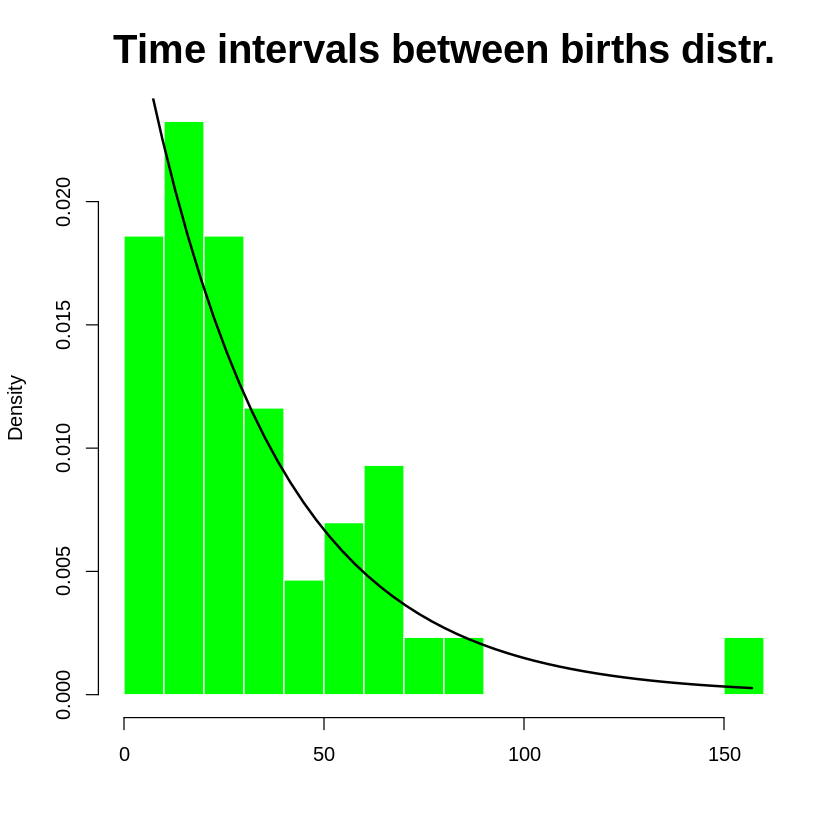

In [57]:
hist(y, col = "green", freq = FALSE, border = "white", xlab = "", main = "Time intervals between births distr.", cex.main = 2, breaks = 20)
x_vals <- seq(0, max(y), length.out = 50)
y_vals <- dexp(x_vals, rate = 1/mean(y))
lines(x_vals, y_vals, lwd = 2)

In [60]:
z <- floor(x %/% 60)
gofstat(fitdist(z, "pois"))

Chi-squared statistic:  419.1799 
Degree of freedom of the Chi-squared distribution:  4 
Chi-squared p-value:  1.993831e-89 
   the p-value may be wrong with some theoretical counts < 5  
Chi-squared table:
       obscounts theocounts
<= 4   9.0000000  0.2066784
<= 10  8.0000000 12.1134664
<= 14  8.0000000 18.7955284
<= 18  7.0000000 10.3339092
<= 20  7.0000000  1.6766389
> 20   5.0000000  0.8737788

Goodness-of-fit criteria
                               1-mle-pois
Akaike's Information Criterion   381.8097
Bayesian Information Criterion   383.5939

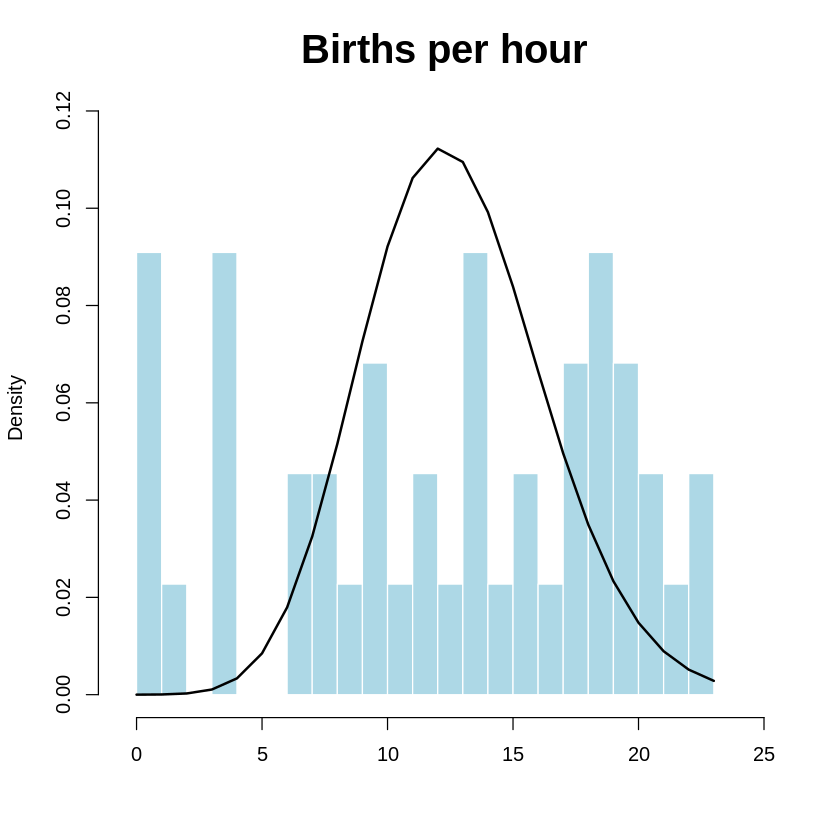

In [71]:
hist(z, col = "lightblue", freq = FALSE, border = "white", xlab = "", main = "Births per hour", cex.main = 2, breaks = 20, xlim = c(-0.5, 25),
     ylim = c(0, max(dpois(0:25, lambda = mean(z))) * 1.05))
x_vals <- 0:23
y_vals <- dpois(x_vals, lambda = mean(z))
lines(x_vals, y_vals, lwd = 2)

Как видим, нулевая гипотеза о пуассоновском характере распределения числа рождений в час отклоняется в пользу альтернативной гипотезы

In [74]:
euroweight <- read.table("/content/R-statistics-spbu/lab2/datasets/euroweight.dat.txt", sep="\t", col.names = c("ID", "weight", "batch"))

In [76]:
func1(euroweight$weight)


Results of Hypothesis Test
--------------------------

Alternative Hypothesis:          

Test Name:                       Lilliefors (Kolmogorov-Smirnov) normality test

Data:                            x

Test Statistic:                  D = 0.0233538

P-value:                         0.01311357

Доверительный интервал для мат. ож.:
[ 7.519725 ,  7.52274 ]

Доверительный интервал для дисперсии:
[ 0.001111943 ,  0.001258763 ]



Вес монет не подчиняется нормальному распределению

In [78]:
for(i in 1:8)
{
  cat("BATCH", i)
  x <- euroweight[euroweight$batch == i, "weight"]
  func1(x)
}

BATCH 1
Results of Hypothesis Test
--------------------------

Alternative Hypothesis:          

Test Name:                       Lilliefors (Kolmogorov-Smirnov) normality test

Data:                            x

Test Statistic:                  D = 0.03847244

P-value:                         0.4900541

Доверительный интервал для мат. ож.:
[ 7.515376 ,  7.523936 ]

Доверительный интервал для дисперсии:
[ 0.0009979416 ,  0.001418991 ]

BATCH 2
Results of Hypothesis Test
--------------------------

Alternative Hypothesis:          

Test Name:                       Lilliefors (Kolmogorov-Smirnov) normality test

Data:                            x

Test Statistic:                  D = 0.03265931

P-value:                         0.7434413

Доверительный интервал для мат. ож.:
[ 7.518748 ,  7.527588 ]

Доверительный интервал для дисперсии:
[ 0.001064311 ,  0.001513363 ]

BATCH 3
Results of Hypothesis Test
--------------------------

Alternative Hypothesis:          

Test Name:         

При этом по отдельности распределение не нормально только в 3м и 8м батчах

In [79]:
iris <- read.table("/content/R-statistics-spbu/lab2/datasets/iris.txt", sep=",", col.names = c("Sepal_length", "Sepal_width", "Petal_length", "Petal_width", "Class"))

In [85]:
col_names <- c("Sepal_length", "Sepal_width", "Petal_length", "Petal_width")
class_names <- c("Iris-setosa", "Iris-versicolor", "Iris-virginica")

result <- matrix(NA, nrow = length(class_names), ncol = length(col_names))
rownames(result) <- class_names
colnames(result) <- col_names

for(i in class_names)
{
  df <- iris[iris$Class == i, col_names]
  for(j in col_names)
  {
    x <- df[[j]]
    cat("======COLUMN ", j, ", CLASS ", i, "======")
    p_val <- func1(x)

    result[i, j] <- ifelse(p_val > 0.05, 1, 0)
  }
}

======COLUMN  Sepal_length , CLASS  Iris-setosa ======
Results of Hypothesis Test
--------------------------

Alternative Hypothesis:          

Test Name:                       Lilliefors (Kolmogorov-Smirnov) normality test

Data:                            x

Test Statistic:                  D = 0.1148599

P-value:                         0.09693248

Доверительный интервал для мат. ож.:
[ 4.905824 ,  5.106176 ]

Доверительный интервал для дисперсии:
[ 0.08669881 ,  0.1929398 ]

======COLUMN  Sepal_width , CLASS  Iris-setosa ======
Results of Hypothesis Test
--------------------------

Alternative Hypothesis:          

Test Name:                       Lilliefors (Kolmogorov-Smirnov) normality test

Data:                            x

Test Statistic:                  D = 0.1148021

P-value:                         0.0972877

Доверительный интервал для мат. ож.:
[ 3.309714 ,  3.526286 ]

Доверительный интервал для дисперсии:
[ 0.1013038 ,  0.2254419 ]

======COLUMN  Petal_length , CLAS

In [86]:
print(result)

                Sepal_length Sepal_width Petal_length Petal_width
Iris-setosa                1           1            0           0
Iris-versicolor            1           1            1           0
Iris-virginica             1           0            1           1


В таблице result единицы стоят на пересечении тех классов и тех признаков для которых гипотеза нормальности подтверждается, 0 - в противном случае